# Phase 1 - Heart Disease Prediction

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Problem Understanding & Data Exploration)  
**Dataset:** Heart Disease Dataset (Kaggle)

This notebook covers:
- Introduction & Problem Statement
- Dataset Selection & Justification
- Initial Data Inspection
- Exploratory Data Analysis (with visualizations)
- Preprocessing Pipeline (with justifications)
- Preprocessed Dataset Ready for Modeling
- Key Insights & Challenges


## 1) Introduction & Problem Statement

Heart disease remains one of the leading causes of death worldwide, making early diagnosis essential for improving patient survival and reducing complications. Many cardiovascular conditions develop silently over time, meaning patients may not receive treatment until severe symptoms appear.
The objective of this project is to build a machine learning-based medical prediction system that classifies whether a patient is likely to have heart disease based on clinical and demographic measurements. Such a system can support early risk assessment and assist healthcare professionals in prioritizing further medical evaluation.
This project falls under the healthcare domain, and it aligns with the course goal of developing a supervised classification advice system during Phase 1.



## 2) Dataset Selection & Justification

**Source (Kaggle):** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

The goal of this dataset is to support medical risk prediction and binary classification, where the task is to determine whether a patient has heart disease based on clinical and demographic measurements. It is commonly used for developing supervised learning models for cardiovascular disease detection.

The dataset is structured in a tabular format and contains **1,025 patient records** with **13 medical features**, in addition to a binary target variable (`target`), where 0 indicates no heart disease and 1 indicates the presence of heart disease.

This dataset was selected because it is clinically relevant, well-structured, and meets Phase 1 requirements in terms of dataset size, feature complexity, and classification classes.

Additionally, the dataset demonstrates high quality and completeness, as it contains no missing values and provides a balanced distribution between the two target classes. These characteristics make it reliable for exploratory analysis and effective supervised learning model development.


## 3) Initial Data Inspection

In [1]:
! pip install pandas numpy openpyxl
import pandas as pd
import numpy as np

# Load dataset
DATA_PATH = "Dataset/HeartDiseaseClevlandDS.xlsx"   

df = pd.read_excel(DATA_PATH)

print("Shape (rows, columns):", df.shape)
df.head()

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement openpyxl (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\reemk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for openpyxl


Shape (rows, columns): (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# Basic info: columns, dtypes, nulls (quick scan)
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nPreview of target distribution:")
print(df["target"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Preview of target distribution:
target
1    526
0    499
Name: count, dtype: int64


## 4) Missing Values

In [4]:
# 4) Missing Values

missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = int(missing_per_col.sum())

print("Total missing values:", total_missing)
display(missing_per_col.to_frame("missing_count").head(20))

Total missing values: 0


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


The dataset was successfully loaded in Python using Pandas.
Initial inspection confirmed:
1,025 observations
14 columns (13 features + target)
No missing values across all columns
The dataset includes both numerical measurements and encoded categorical clinical attributes.

## 5) Target Class Distribution

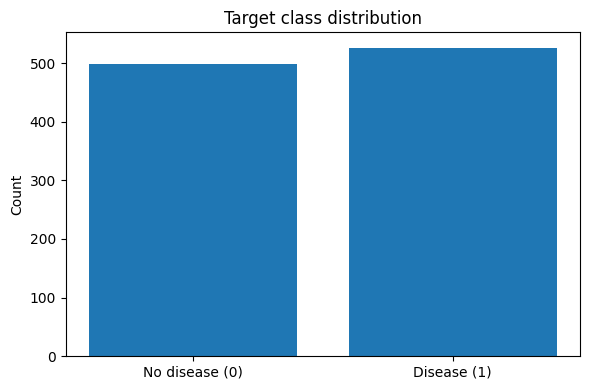

Counts:
target
0    499
1    526
Name: count, dtype: int64

Class balance (%):
target
0    48.68
1    51.32
Name: count, dtype: float64


In [5]:
# 5) Target Class Distribution

import matplotlib.pyplot as plt

counts = df["target"].value_counts().sort_index()
labels = ["No disease (0)", "Disease (1)"]

plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title("Target class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Counts:")
print(counts)
print("\nClass balance (%):")
print((counts / counts.sum() * 100).round(2))

## 6) Descriptive Statistics

We compute summary statistics (mean, std, min/max, quartiles) to understand the ranges and variability of numeric features.


In [6]:
# Descriptive statistics for numeric columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 7) Feature Distributions (Histograms)

Histograms show how each numeric feature is distributed across the dataset.


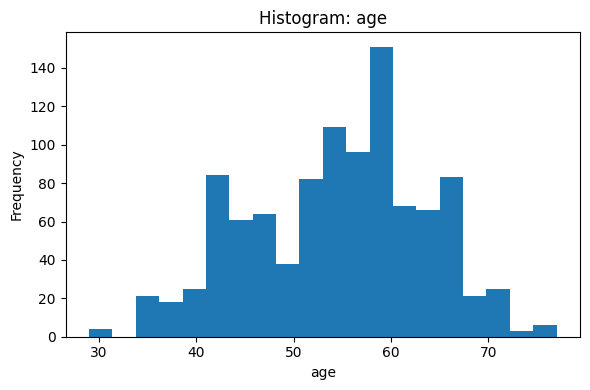

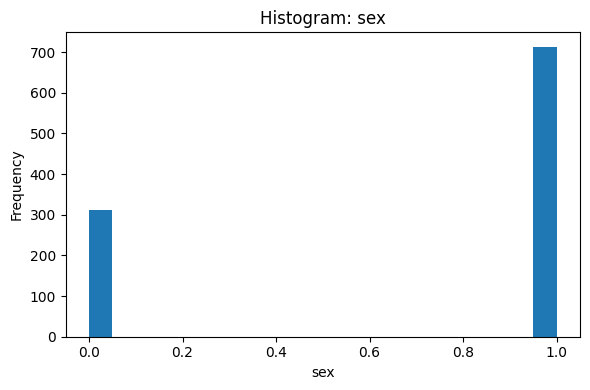

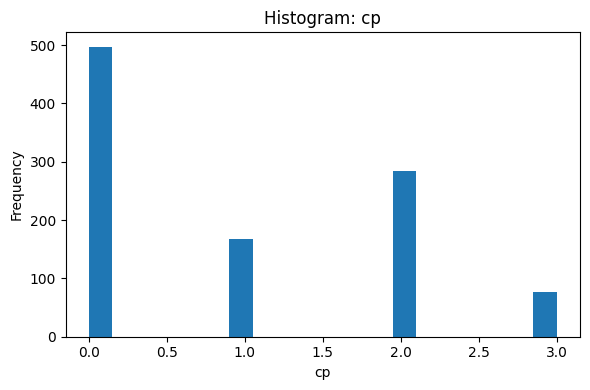

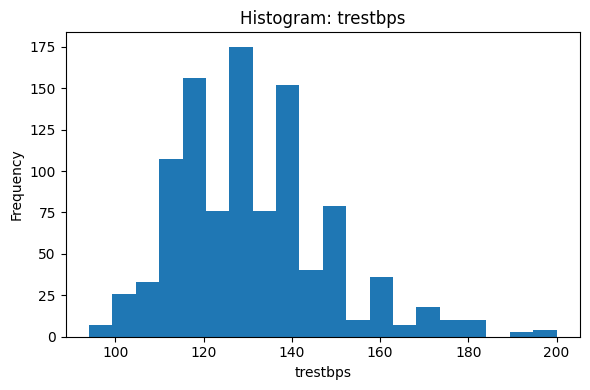

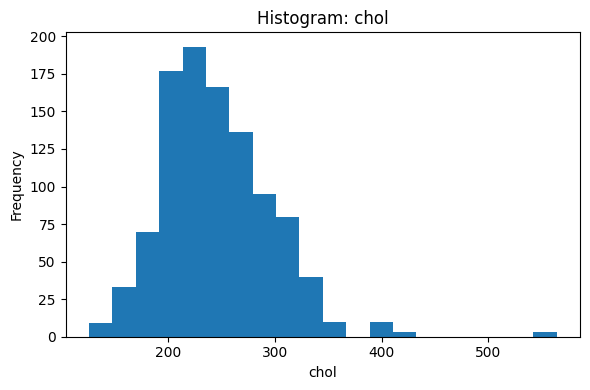

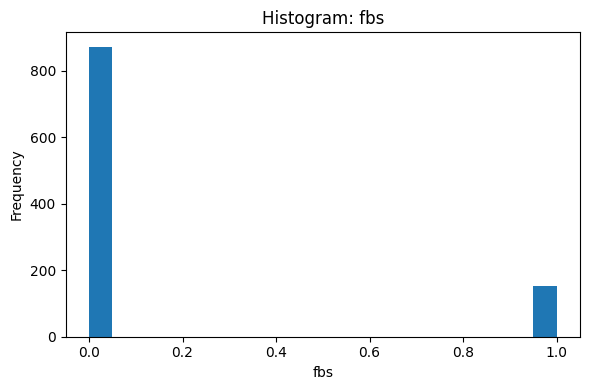

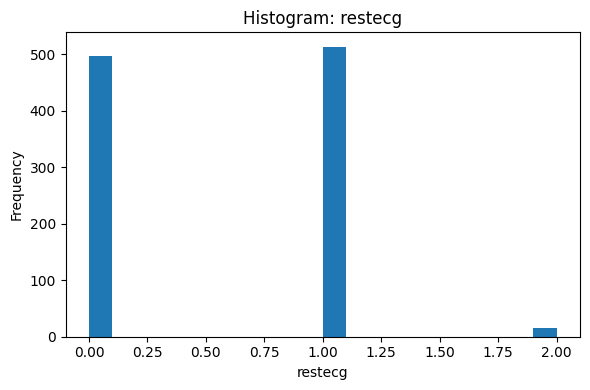

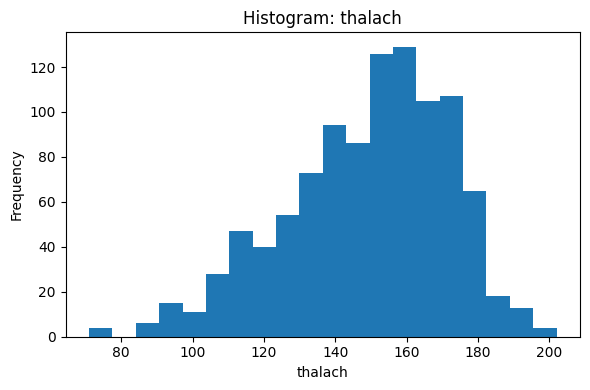

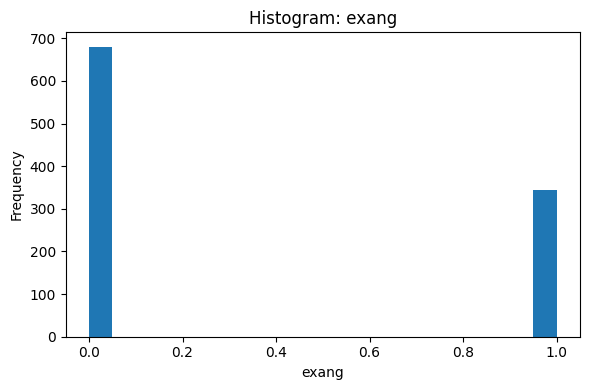

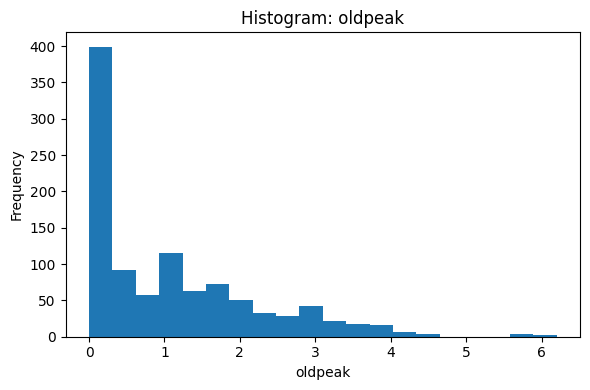

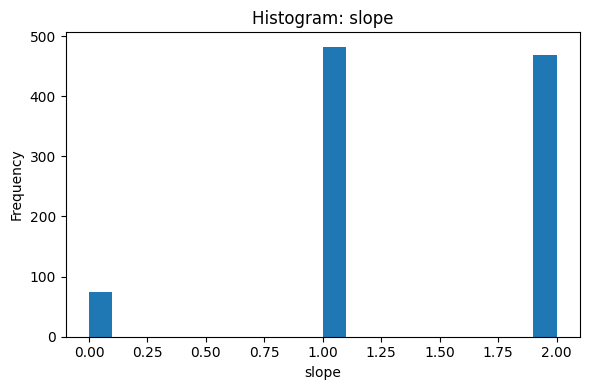

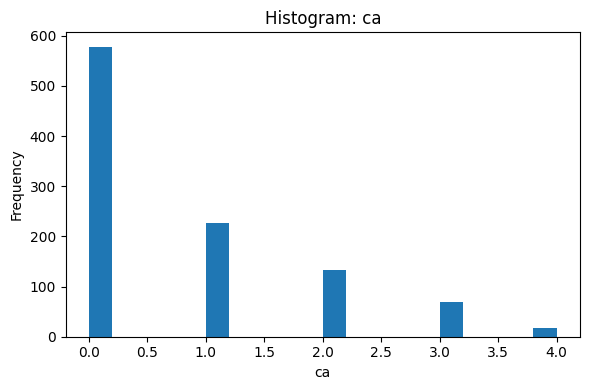

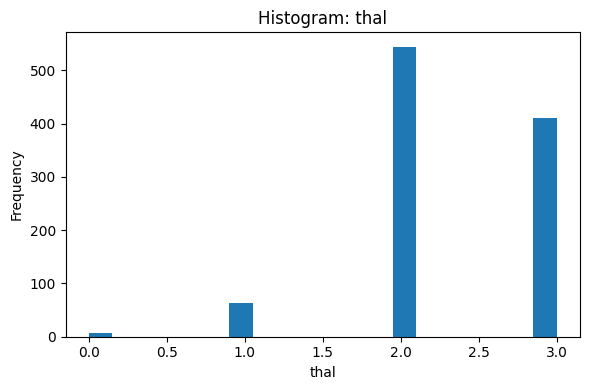

In [7]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target from distribution plots (optional)
numeric_feature_cols = [c for c in numeric_cols if c != "target"]

for col in numeric_feature_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 8) Outliers & Spread (Box Plots)

Box plots help detect outliers and compare the spread of each numeric feature.


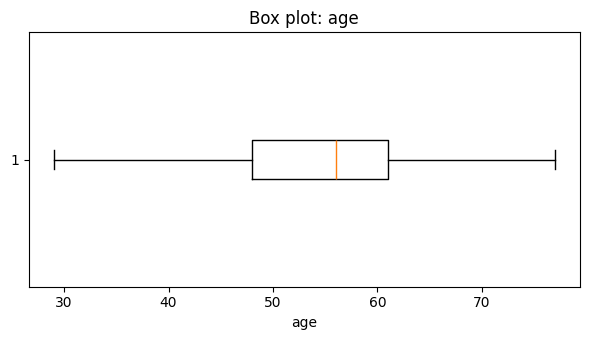

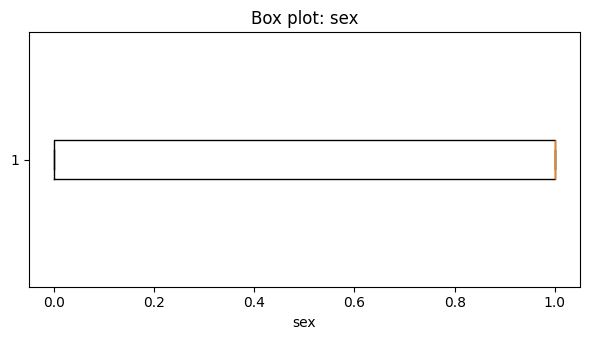

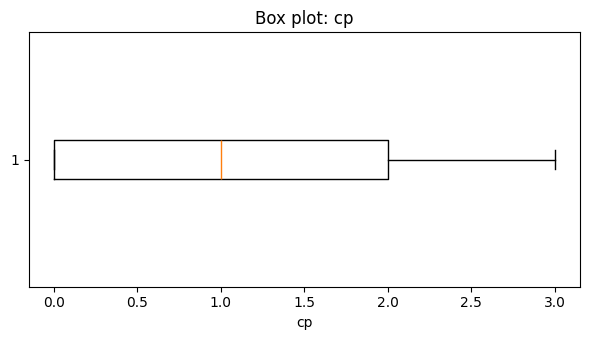

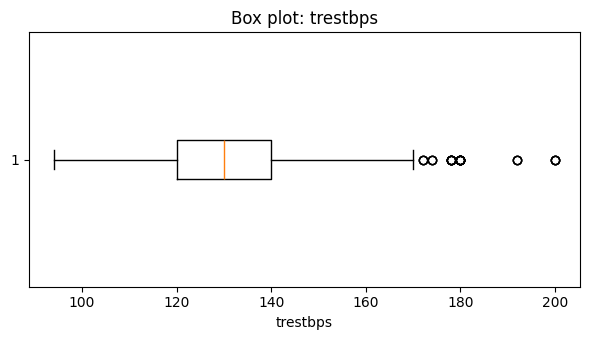

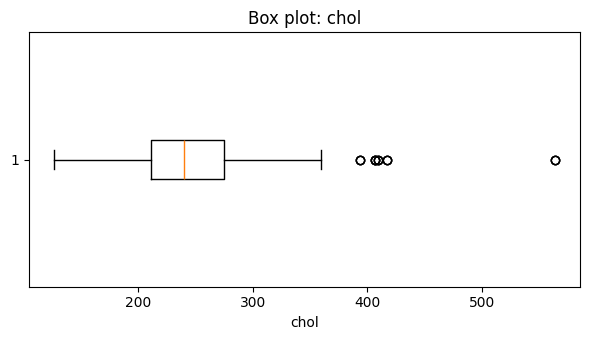

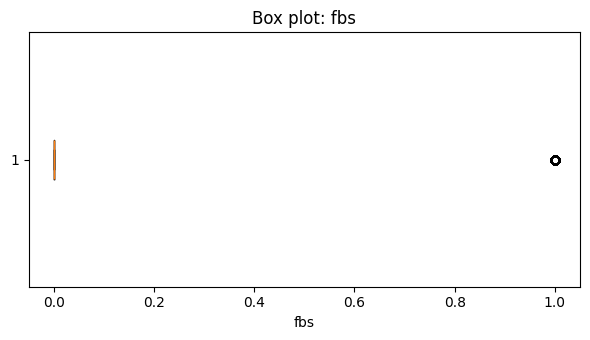

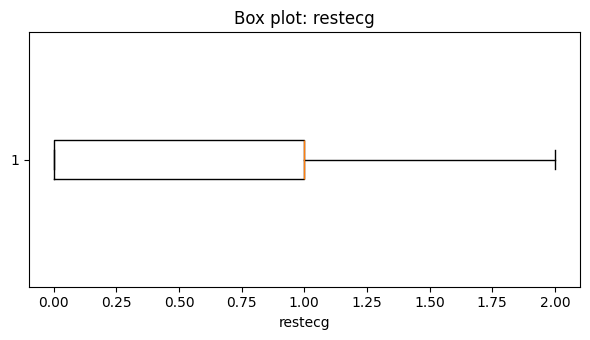

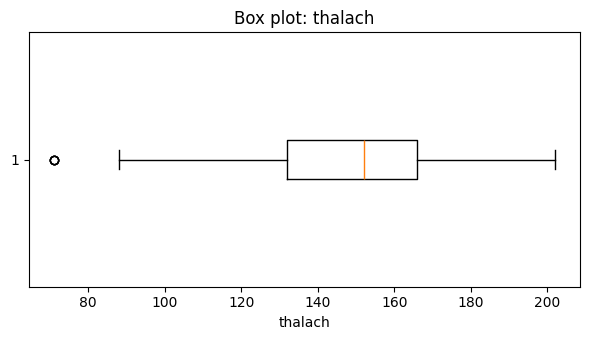

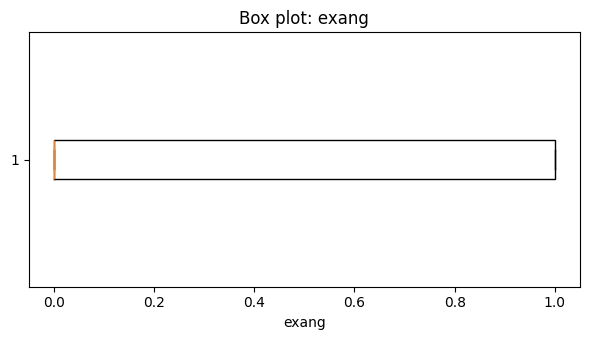

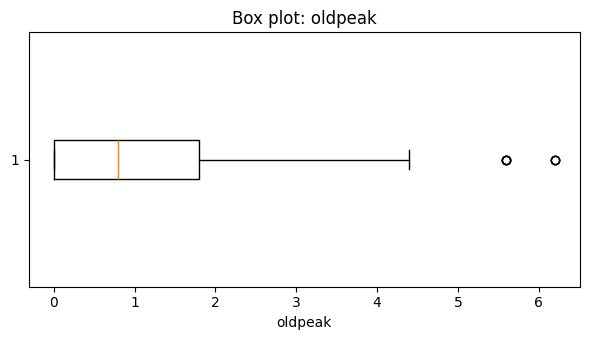

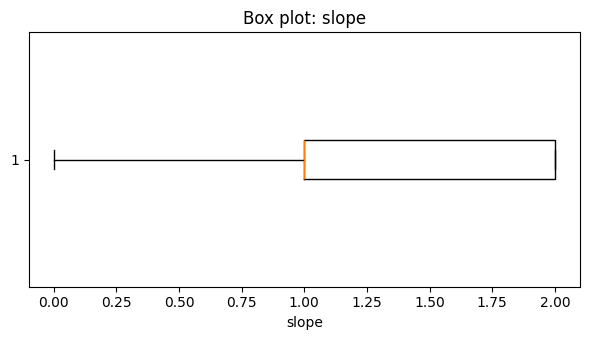

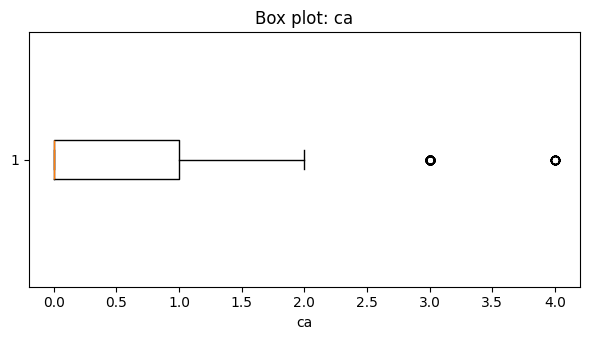

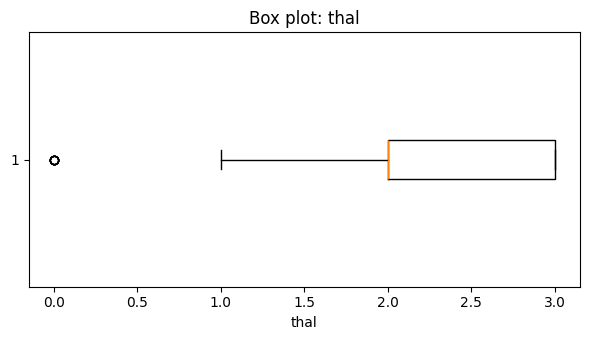

In [8]:
import matplotlib.pyplot as plt

for col in numeric_feature_cols:
    plt.figure(figsize=(6,3.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box plot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 9) Correlation Analysis

We compute correlations between numeric features and visualize them as a heatmap.  
This helps identify strongly related variables and potential predictive signals for modeling.


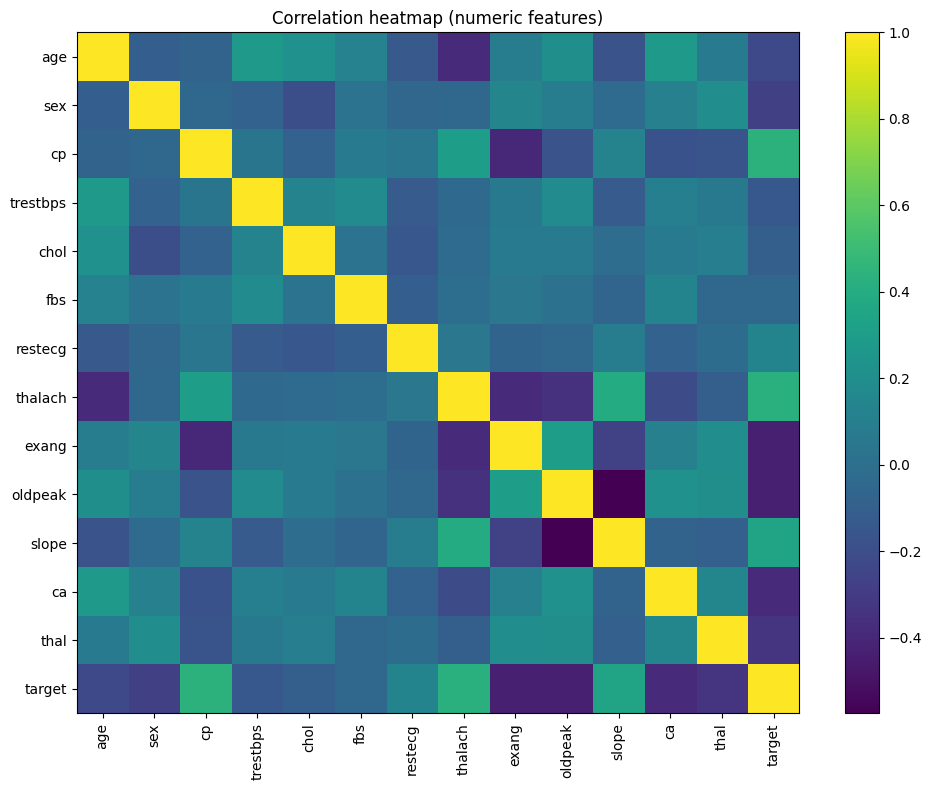

Top correlations with target (by absolute value):


,corr_with_target
oldpeak,-0.438441
exang,-0.438029
cp,0.434854
thalach,0.422895
ca,-0.382085
slope,0.345512
thal,-0.337838
sex,-0.279501
age,-0.229324
trestbps,-0.138772


In [9]:
import numpy as np
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

# Show top correlations with the target (if target is numeric 0/1)
if "target" in corr.columns:
    target_corr = corr["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
    print("Top correlations with target (by absolute value):")
    display(target_corr.to_frame("corr_with_target"))

### 9.1) backwards mapping fixed
The correlation heatmap revealed illogical relationships between several features and the target variable. For example, the initial mapping suggested that lower cholesterol levels were associated with a higher probability of heart disease, which contradicts medical knowledge.
Additionally, multiple features showed inverse (negative) correlations, indicating a possible mislabeling between diseased and non-diseased patients. Based on these observations, the backward mapping was corrected, and the target variable was redefined as IsHeartDisease to ensure clear and medically consistent classification.

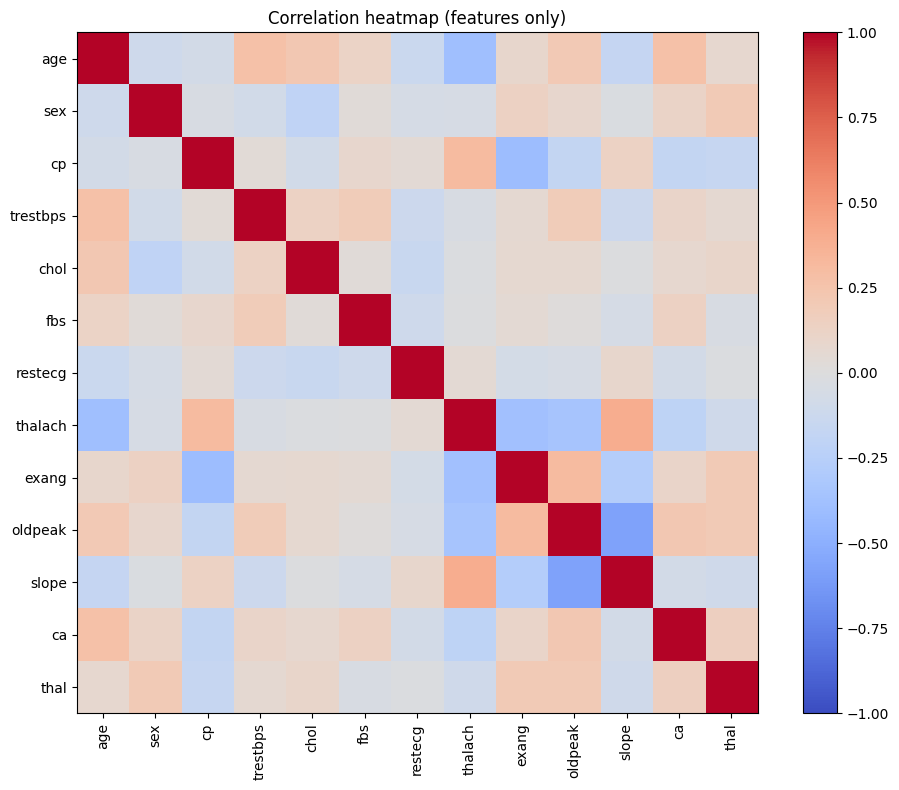

Top correlations with IsHeartDisease:


,corr_with_IsHeartDisease
oldpeak,0.438441
exang,0.438029
cp,-0.434854
thalach,-0.422895
ca,0.382085
slope,-0.345512
thal,0.337838
sex,0.279501
age,0.229324
trestbps,0.138772


In [30]:
import numpy as np
import matplotlib.pyplot as plt

CorrectMapping_df = df.copy()

# Map target: 0 = disease, 1 = no disease  →  IsHeartDisease: 1 = disease, 0 = no disease
CorrectMapping_df["IsHeartDisease"] = (CorrectMapping_df["target"] == 0).astype(int)

# drop old target columns to avoid confusion
CorrectMapping_df.drop(columns=["target"], inplace=True)

# validate correct correlations with isHeaIsHeartDisease clasification attribute
corr = CorrectMapping_df.select_dtypes(include=[np.number]).corr()
corr_features = corr.drop(index="IsHeartDisease", columns="IsHeartDisease")

plt.figure(figsize=(10,8))
plt.imshow(corr_features.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_features.columns)), corr_features.columns, rotation=90)
plt.yticks(range(len(corr_features.columns)), corr_features.columns)
plt.title("Correlation heatmap (features only)")
plt.tight_layout()
plt.show()

# Show top correlations
target_corr = (
    CorrectMapping_df
    .select_dtypes(include=[np.number])
    .corr()["IsHeartDisease"]
    .drop("IsHeartDisease")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top correlations with IsHeartDisease:")
display(target_corr.to_frame("corr_with_IsHeartDisease"))

## 10) Correlation pattern between features

Scatter plot helps understand the the correlation pattern between features. 
This helps to identify non-linear relation between two features.


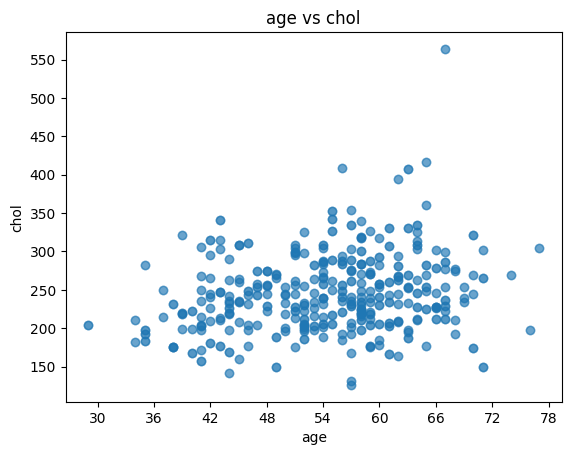

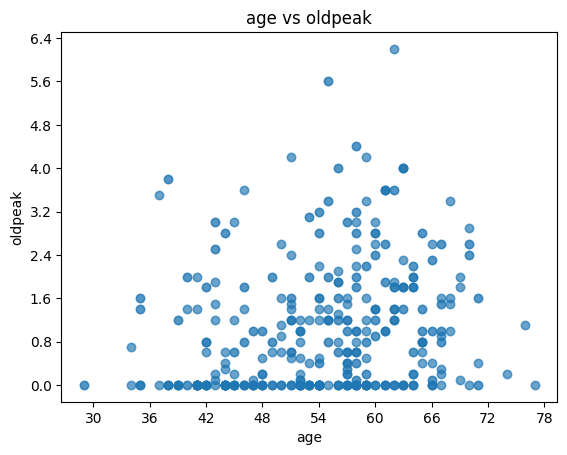

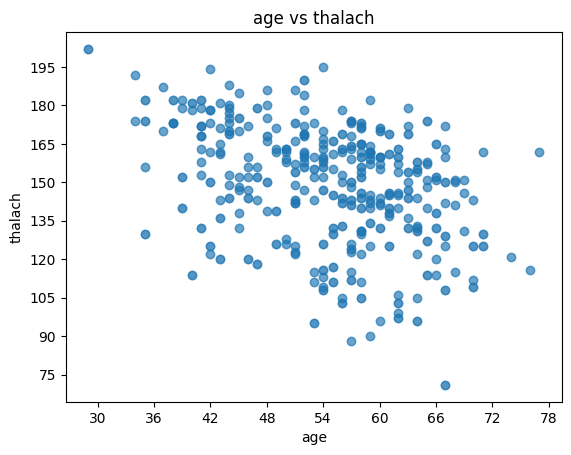

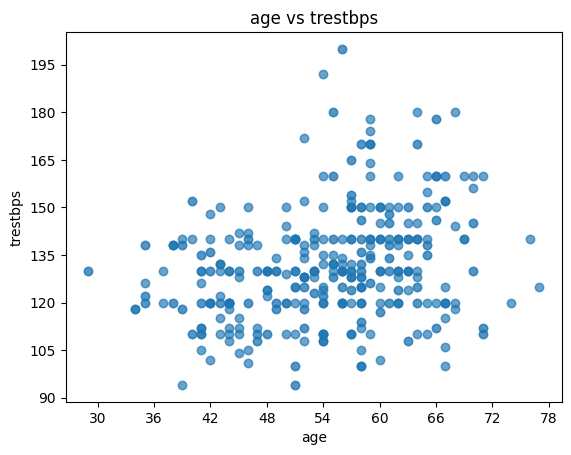

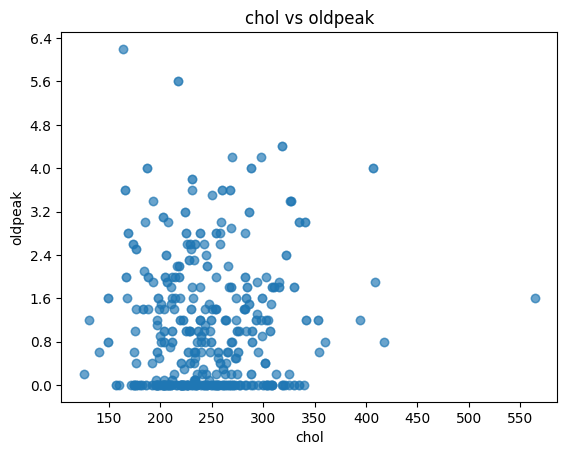

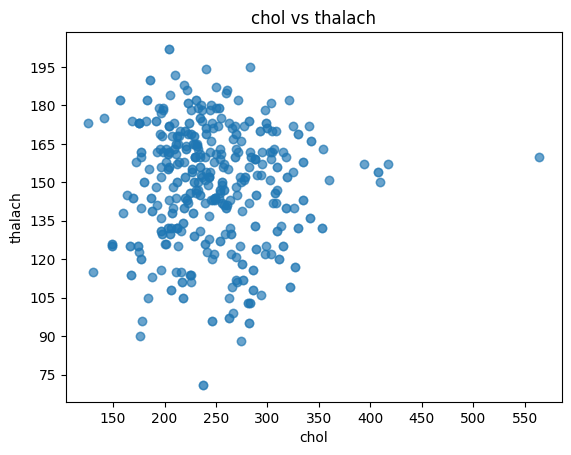

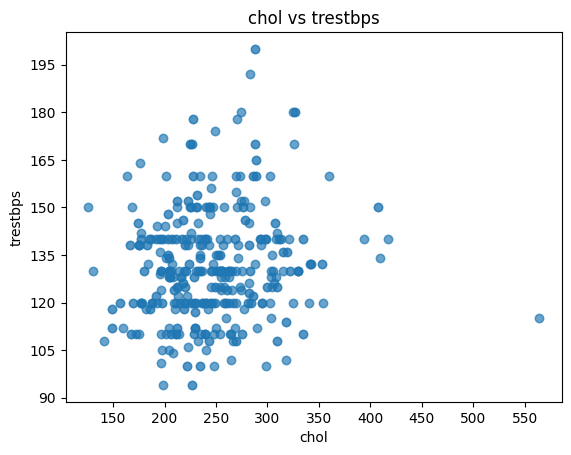

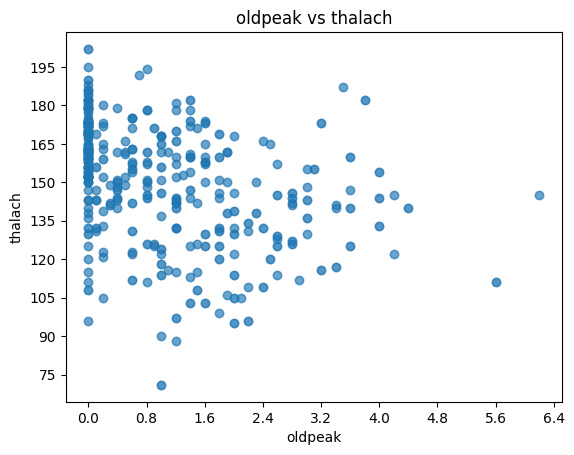

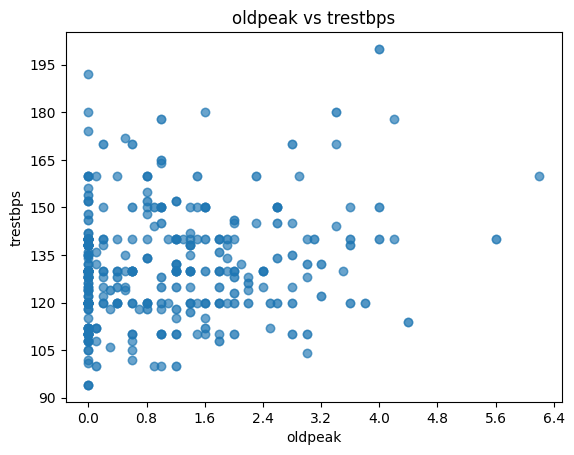

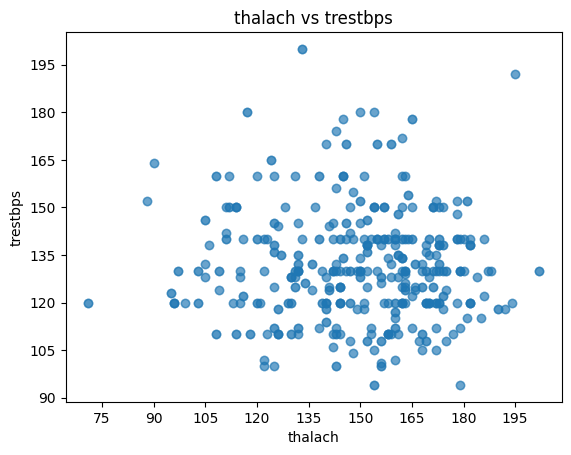

In [13]:
from itertools import combinations
from matplotlib.ticker import MaxNLocator

continuous_cols = ['age', 'chol', 'oldpeak', 'thalach','trestbps']

for x_col, y_col in combinations(continuous_cols, 2):
    plt.figure()
    plt.scatter(CorrectMapping_df[x_col], CorrectMapping_df[y_col], alpha=0.3)
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10))
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.show()


## 10) Feature vs Target (Group Comparison)

We compare numeric feature means across the two IsHeartDisease classes (0 vs 1) to get an initial sense of which features differ between classes.

In [31]:
group_means = CorrectMapping_df.groupby("IsHeartDisease")[numeric_feature_cols].mean().T
group_means.columns = ["mean_IsHeartDisease_0", "mean_IsHeartDisease_1"]
group_means["diff_(1-0)"] = group_means["mean_IsHeartDisease_1"] - group_means["mean_IsHeartDisease_0"]
group_means.sort_values(by="diff_(1-0)", key=lambda s: s.abs(), ascending=False).head(20)

,mean_IsHeartDisease_0,mean_IsHeartDisease_1,diff_(1-0)
thalach,158.585551,139.130261,-19.455291
chol,240.979087,251.292585,10.313498
trestbps,129.245247,134.106212,4.860965
age,52.408745,56.569138,4.160393
oldpeak,0.569962,1.600200,1.030238
cp,1.378327,0.482966,-0.895361
ca,0.370722,1.158317,0.787594
slope,1.593156,1.166333,-0.426823
thal,2.119772,2.539078,0.419306
exang,0.134981,0.549098,0.414117


## 11) Key Insights & Challenges

Key findings from the EDA include:
- The dataset contains no missing values, indicating high completeness.
- Target classes are relatively balanced (526 vs 499), reducing class imbalance concerns.
- Several features show strong relationships with heart disease outcomes, particularly oldpeak, exang, chest pain type, and maximum heart rate.
- A potential challenge is the presence of outliers in some clinical measurements, which may require scaling or robust preprocessing in the next phase.

## 12) Data Preprocessing






### 12.1 Normalization 

Normalization is the process of transforming continuous numerical features into a comparable scale. 
Without feature scaling, machine learning models may assign excessive importance to features with wider numerical ranges while underestimating features with smaller ranges.

Multiple normalization techniques can be applied depending on the feature data distribution as well as the presence of outliers. 
The following table summarizes the normalization techniques used in this study and the situations in which each technique is most appropriate.

| Normalization Technique | Formula | Distribution Type | Outlier Sensitivity |
| :--- | :---: | :---: | :---: |
| Z-score Standardization | $x_{scaled}=\frac{x-\mu}{\sigma}$ | Approximately normal or symmetric distribution | Sensitive |
| Log Transformation | $x_{scaled}= \log(x)$ | Right-skewed distribution | Reduces effect of extreme values |
| RobustScaler | $x_{scaled}=\frac{x-\text{Median}(x)}{Q_{3}-Q_{1}}$ | Approximately normal or Moderate skew with outliers | Low sensitivity |
| Linear scaling| $x_{scaled}=\frac{x-x_{min}}{x_{max}-x_{min}}$| Approximately uniform distribution|Sensitive|

The feature distribution type can be visually assessed using histogram diagrams, while the existence of outliers can be identified through boxplot diagrams. 
However, visual inspection alone may be misleading; therefore, statistical measurements such as the skewness coefficient were also calculated using the `skew()` function to quantitatively evaluate distribution symmetry.
The following table illustrate the skewness coefficient ranges:

| Skewness coefficient range |Distribution Type |
| :--- | :---: |
|between -0.5 and 0.5 but not 0 |approximately normal|
|between -1 and -0.5 or between 0.5 and 1|moderately skewed|
|grater than 1 ot less than -1 |highly skewed|



#### 12.1.1 Age Feature Normalization

##### - Distribution Analysis

Based on the previous Age histogram and boxplot diagrams:

- The histogram shows an approximately symmetric distribution.
- The boxplot shows balanced whiskers and doesn't show any outliers.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the age feature.

In [32]:
print("The skewness coefficient of Age:", CorrectMapping_df['age'].skew())

The skewness coefficient of Age: -0.24886590174584555


##### - Interpretation

The skewness coefficient of the age is within the approximately symmetric distribution range (-0.5 to 0.5).
Since there are no outliers and the distribution is approximately symmetric, we will use Z-score standardization.

,Before Scaling,After Scaling
0,52,-0.268437
1,53,-0.158157
2,70,1.716595
3,61,0.724079
4,62,0.834359


Mean: -3.431401504402435e-16
Std: 1.0004881620988828


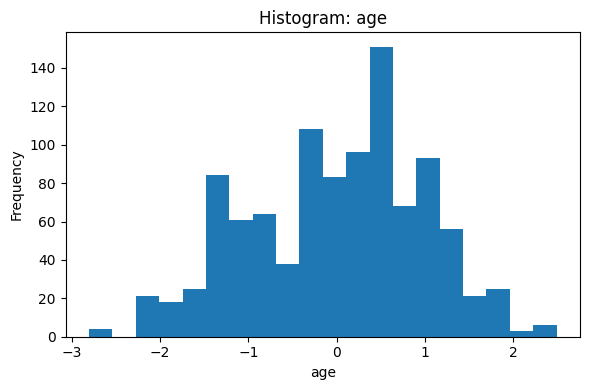

In [44]:
from sklearn.preprocessing import StandardScaler

PreProcessd_df = CorrectMapping_df.copy()

age_before=CorrectMapping_df['age']
scaler = StandardScaler()
PreProcessd_df['age'] = scaler.fit_transform(PreProcessd_df[['age']])

#prove the success of the normalization
age_comparison_table = pd.concat(
    [age_before.head(), PreProcessd_df['age'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(age_comparison_table)

print("Mean:", PreProcessd_df['age'].mean())
print("Std:", PreProcessd_df['age'].std())

plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['age'].dropna(), bins=20)
plt.title(f"Histogram: {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 12.1.2 Trestbps Feature Normalization

##### - Distribution Analysis

Based on the previous Trestbps histogram and boxplot diagrams:

- The histogram shows a positive skewness.
- The boxplot contains several outliers.

To quantitatively prove these observations, we will calculate the skewness coefficient for the trestbps feature.

In [45]:
print("The skewness coefficient of trestbps:", PreProcessd_df['trestbps'].skew())

The skewness coefficient of trestbps: 0.739768226050074


##### - Interpretation

The skewness coefficient of the trestbps is within the moderate positive skewness range (0.5 to 1).
Since there are outliers and the skewness is not high, the RobustScaler was selected as a more appropriate normalization technique.

,Before Scaling,After Scaling
0,125,-0.25
1,140,0.50
2,145,0.75
3,148,0.90
4,138,0.40


Median: 0.0
Q1: -0.5
Q3: 0.5


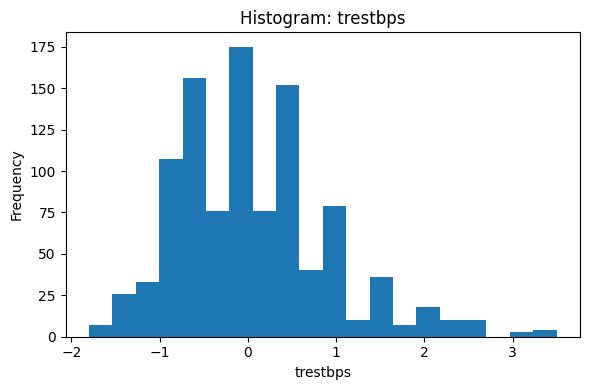

In [46]:
from sklearn.preprocessing import RobustScaler

trestbps_before=PreProcessd_df['trestbps'].copy()

scaler = RobustScaler()

PreProcessd_df['trestbps'] = scaler.fit_transform(PreProcessd_df[['trestbps']])


#prove the success of the normalization 
trestbps_comparison_table = pd.concat(
    [trestbps_before.head(), PreProcessd_df['trestbps'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(trestbps_comparison_table)

print("Median:", PreProcessd_df['trestbps'].median())
print("Q1:", PreProcessd_df['trestbps'].quantile(0.25))
print("Q3:", PreProcessd_df['trestbps'].quantile(0.75))

plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['trestbps'].dropna(), bins=20)
plt.title(f"Histogram: {'trestbps'}")
plt.xlabel('trestbps')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 12.1.3 Thalach Feature Normalization

##### -Distribution Analysis

Based on the previous Thalach histogram and boxplot diagrams:

- The histogram shows an approximately normal distribution.
- The boxplot indicates balanced whiskers with only one outlier.

To quantitatively prove these observations, we will calculate the skewness coefficient for the thalach feature.

In [47]:
print("The skewness coefficient of Cholesterol:", PreProcessd_df['thalach'].skew())

The skewness coefficient of Cholesterol: -0.5137771771417209


##### - Interpretation

The skewness coefficient of the thalach is within the moderate negative skewness range (-0.5 to -1).

Since the outliers and the asymmetry are slight and insignificant, they will not affect the normalization. Therefore, we will use the Z-score standardization.

,Before Scaling,After Scaling
0,168,0.821321
1,155,0.255968
2,125,-1.048692
3,161,0.516900
4,106,-1.874977


Mean: -4.3325776570737815e-16
Std: 1.0004881620988826


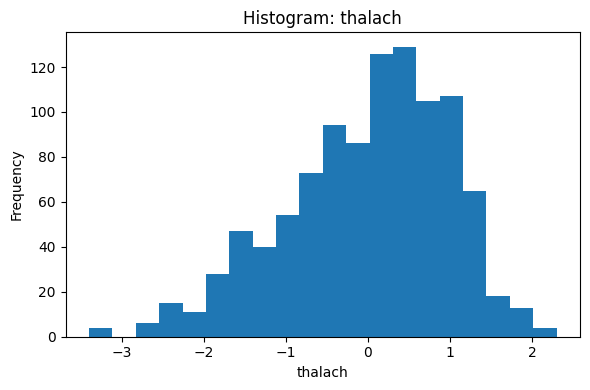

In [48]:
from sklearn.preprocessing import StandardScaler

thalach_before=PreProcessd_df['thalach'].copy()

scaler = StandardScaler()
PreProcessd_df['thalach'] = scaler.fit_transform(df[['thalach']])

#prove the success of the normalization 
thalach_comparison_table = pd.concat(
    [thalach_before.head(), PreProcessd_df['thalach'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(thalach_comparison_table)

print("Mean:", PreProcessd_df['thalach'].mean())
print("Std:", PreProcessd_df['thalach'].std())


plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['thalach'].dropna(), bins=20)
plt.title(f"Histogram: {'thalach'}")
plt.xlabel('thalach')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 12.1.4 Oldpeak Feature Normalization

##### -Distribution Analysis

Based on the previous Oldpeak histogram and boxplot diagrams:

- The histogram shows a positive skewness distribution with a large values concentration near zero.
- The boxplot has several outliers beyond the upper whisker.

To quantitatively prove these observations, we will calculate the skewness coefficient for the oldpeak feature.

In [49]:
print("The skewness coefficient of Cholesterol:", PreProcessd_df['oldpeak'].skew())

The skewness coefficient of Cholesterol: 1.2108993882065326


##### -Interpretation

The skewness coefficient of the oldpeak is larger than 1, indicating strong positive skewness.

The feature contains several outliers, and both the histogram and the skewness coefficient show a strong right skewness. However, since these values may represent important clinically cases, removing them may result in the loss of important medical information. Therefore, a logarithmic transformation was applied to reduce skewness and compress large values before applying Z-score standardization.

,Before Scaling,After Scaling
0,1.0,0.206584
1,3.1,1.567082
2,2.6,1.320597
3,0.0,-1.107114
4,1.9,0.910796


Mean: 8.491852207864612e-17
Std: 1.0004881620988826
The skewness coefficient of oldpeak after the normalization: 0.35790878702158047


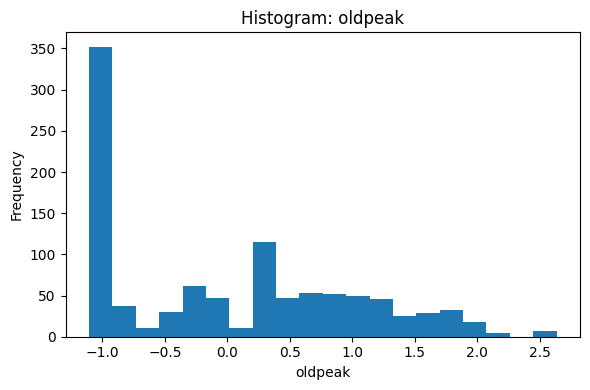

In [50]:
import numpy as np


oldpeak_before = PreProcessd_df['oldpeak'].copy()

PreProcessd_df['oldpeak'] = np.log1p(PreProcessd_df['oldpeak'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

PreProcessd_df['oldpeak'] = scaler.fit_transform(PreProcessd_df[['oldpeak']])


#prove the success of the normalization 
oldpeak_comparison_table = pd.concat(
    [oldpeak_before.head(), PreProcessd_df['oldpeak'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(oldpeak_comparison_table)

print("Mean:", PreProcessd_df['oldpeak'].mean())
print("Std:", PreProcessd_df['oldpeak'].std())
print("The skewness coefficient of oldpeak after the normalization:", PreProcessd_df['oldpeak'].skew())


plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['oldpeak'].dropna(), bins=20)
plt.title(f"Histogram: {'oldpeak'}")
plt.xlabel('oldpeak')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 12.2 Discretization
Discretization was not applied to most continuous variables to preserve numerical precision and the gradual nature of cardiovascular risk. However, cholesterol was discretized using established clinical thresholds, as cardiovascular risk is assessed based on risk categories (e.g., normal, borderline high, and high) rather than precise numeric values. As shown in Figure 1, the presence of extreme cholesterol values further supports discretization to improve interpretability and reduce their influence.

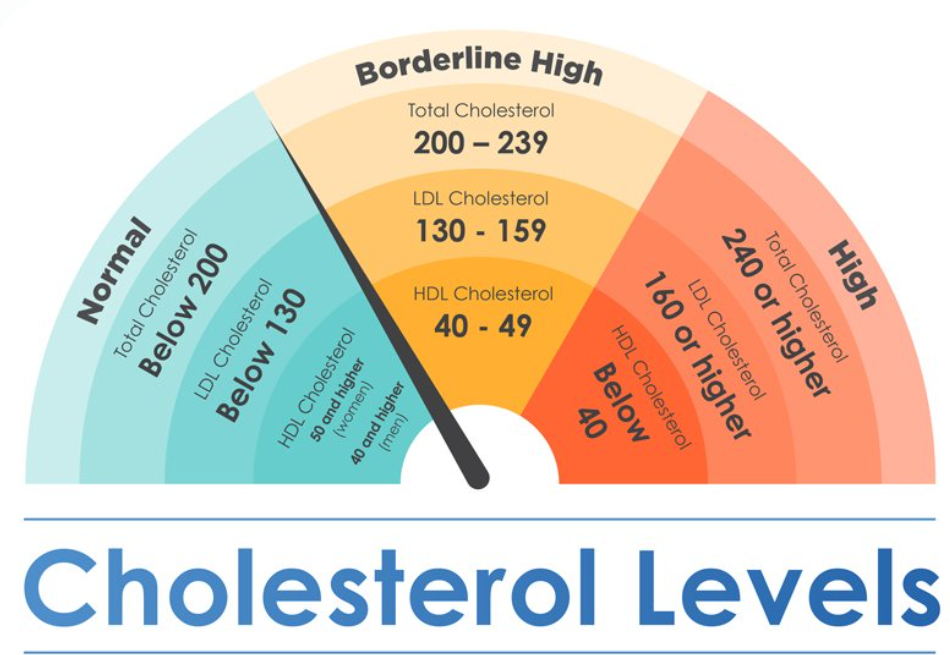

**Figure 1.** Distribution of cholesterol values showing the presence of clinically distinct risk ranges and extreme values. [Source: Modern Heart and Vascular (2024)](https://www.modernheartandvascular.com/high-cholesterol-and-heart-disease/)

In [51]:
from IPython.display import Image, display, Markdown

display(Image(filename="images/CholesterolMeasure.png", width=450))

display(Markdown(
    "**Figure 1.** Distribution of cholesterol values showing the presence of clinically distinct risk ranges and extreme values. "
    "[Source: Modern Heart and Vascular (2024)](https://www.modernheartandvascular.com/high-cholesterol-and-heart-disease/)"
))

In [52]:
import numpy as np
import pandas as pd

# Discretize cholesterol into clinically defined risk categories
chol_bins = [0, 200, 240, np.inf]
chol_labels = ['Normal', 'Borderline High', 'High']

PreProcessd_df['chol_category'] = pd.cut(
    PreProcessd_df['chol'],
    bins=chol_bins,
    labels=chol_labels,
    right=False
)

# Cholesterol risk category thresholds (clinical reference)
chol_mapping = pd.DataFrame({
    'Cholesterol Range (mg/dL)': ['< 200', '200–239', '≥ 240'],
    'Risk Category': chol_labels
})

# Distribution of cholesterol categories in the dataset
chol_distribution = (
    PreProcessd_df['chol_category']
    .value_counts()
    .rename_axis('Cholesterol Category')
    .reset_index(name='Number of Patients')
)

display(chol_mapping)
display(chol_distribution)

# Remove original cholesterol values to avoid redundant representation
PreProcessd_df.drop(columns=['chol'], inplace=True)

,Cholesterol Range (mg/dL),Risk Category
0,< 200,Normal
1,200–239,Borderline High
2,≥ 240,High


,Cholesterol Category,Number of Patients
0,High,517
1,Borderline High,339
2,Normal,169


### 12.3 Encoding
Categorical variables (cp, restecg, slope, ca, thal, and the discretized cholesterol category) were encoded using one-hot encoding because their numerical values represent distinct medical categories rather than ordered or equally spaced quantities. Applying one-hot encoding prevents the models from assuming artificial linear ordering or equal distances between categories and allows them to learn the effect of each category on the classification outcome directly from the data. Binary variables (sex, fbs, and exang) were retained in their original 0/1 format, as this representation is already suitable for classification models.

In [53]:
import pandas as pd

# Nominal and discretized categorical variables to encode
categorical_vars = ['cp', 'restecg', 'slope', 'ca', 'thal', 'chol_category']

print("Before Encoding:")
display(PreProcessd_df.head())

# Apply one-hot encoding
PreProcessd_df = pd.get_dummies(PreProcessd_df, columns=categorical_vars, drop_first=True)

# Convert to 0/1
bool_cols = PreProcessd_df.select_dtypes(include='bool').columns
PreProcessd_df[bool_cols] = PreProcessd_df[bool_cols].astype(int)

print("\nAfter Encoding:")
display(PreProcessd_df.head())

Before Encoding:


,age,sex,cp,trestbps,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,IsHeartDisease,chol_category
0,-0.268437,1,0,-0.25,0,1,0.821321,0,0.206584,2,2,3,1,Borderline High
1,-0.158157,1,0,0.50,1,0,0.255968,1,1.567082,0,0,3,1,Borderline High
2,1.716595,1,0,0.75,0,1,-1.048692,1,1.320597,0,0,3,1,Normal
3,0.724079,1,0,0.90,0,1,0.516900,0,-1.107114,2,1,3,1,Borderline High
4,0.834359,0,0,0.40,1,1,-1.874977,0,0.910796,1,3,2,1,High



After Encoding:


,age,sex,trestbps,fbs,thalach,exang,oldpeak,IsHeartDisease,cp_1,cp_2,...,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3,chol_category_Borderline High,chol_category_High
0,-0.268437,1,-0.25,0,0.821321,0,0.206584,1,0,0,...,1,0,1,0,0,0,0,1,1,0
1,-0.158157,1,0.50,1,0.255968,1,1.567082,1,0,0,...,0,0,0,0,0,0,0,1,1,0
2,1.716595,1,0.75,0,-1.048692,1,1.320597,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.724079,1,0.90,0,0.516900,0,-1.107114,1,0,0,...,1,1,0,0,0,0,0,1,1,0
4,0.834359,0,0.40,1,-1.874977,0,0.910796,1,0,0,...,0,0,0,1,0,0,1,0,0,1


### 12.4 Variable Removal
No variables were removed during preprocessing, as all features were clinically relevant and no variables exhibited constant values or excessive missing data. Removing variables without proper statistical or medical justification could result in unnecessary information loss and reduced predictive performance.